In [1]:
from evolving_agents.graph import build_belief_graph
from evolving_agents.visualize import draw_graph



In [2]:
from evolving_agents.thought import thought_step
from collections import Counter



In [3]:
from evolving_agents.thought import thought_loop


In [4]:
G = build_belief_graph()
trace = thought_loop(G, "survival", max_steps=8)
print(" -> ".join(trace))

survival -> food -> rest -> survival -> food -> rest -> survival -> danger -> safety


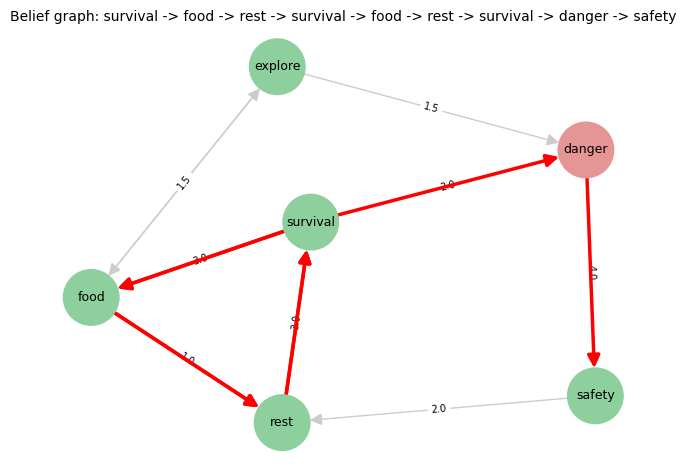

In [5]:
draw_graph(G, path=trace)     # the path argument lights up the route in red


In [6]:
from evolving_agents.metrics import coverage


In [7]:
G = build_belief_graph()
for i in range(4):
    trace = thought_loop(G, "survival", max_steps=10)
    print(f"coverage={coverage(G, trace)}   {' -> '.join(trace)}")

coverage=1.0   survival -> food -> explore -> danger -> safety -> rest -> survival -> danger -> safety -> rest -> survival
coverage=1.0   survival -> danger -> safety -> rest -> survival -> food -> explore -> danger -> safety -> rest -> survival
coverage=1.0   survival -> food -> explore -> food -> explore -> danger -> safety -> rest -> survival -> food -> explore
coverage=1.0   survival -> food -> rest -> survival -> food -> explore -> food -> rest -> survival -> danger -> safety


thought 1: coverage=1.0  payoff=15.0
   survival -> danger -> safety -> rest -> survival -> danger -> safety -> rest -> survival -> food -> explore

thought 2: coverage=1.0  payoff=15.0
   survival -> food -> explore -> danger -> safety -> rest -> survival -> food -> explore -> food -> explore

thought 3: coverage=0.67  payoff=8.0
   survival -> danger -> safety -> rest -> survival -> danger -> safety -> rest -> survival -> danger -> safety

thought 4: coverage=1.0  payoff=15.0
   survival -> danger -> safety -> rest -> survival -> food -> explore -> food -> explore -> food -> explore



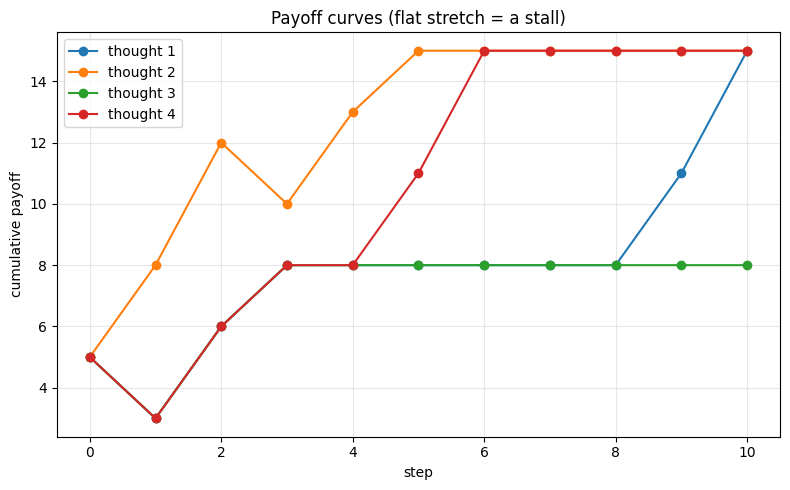

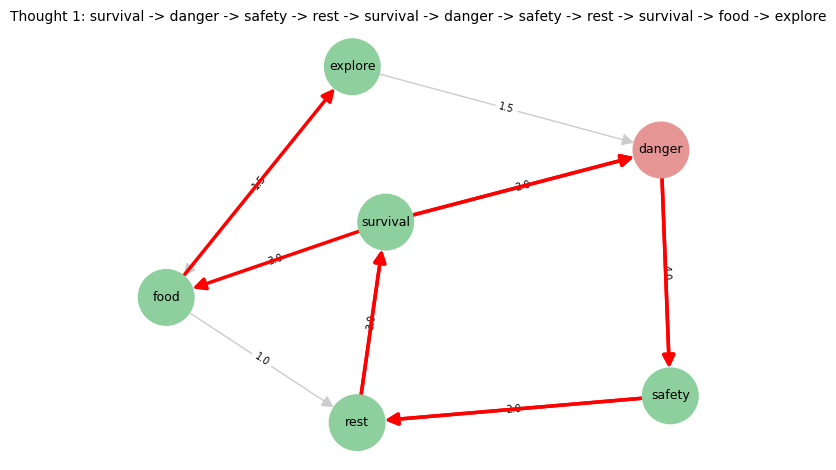

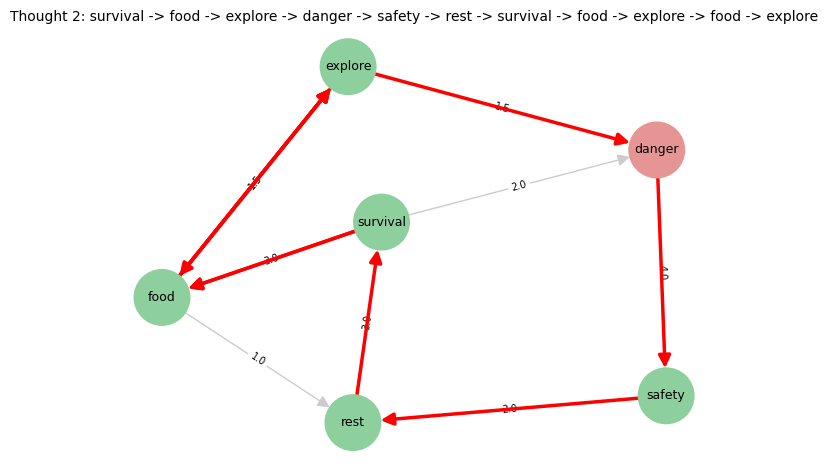

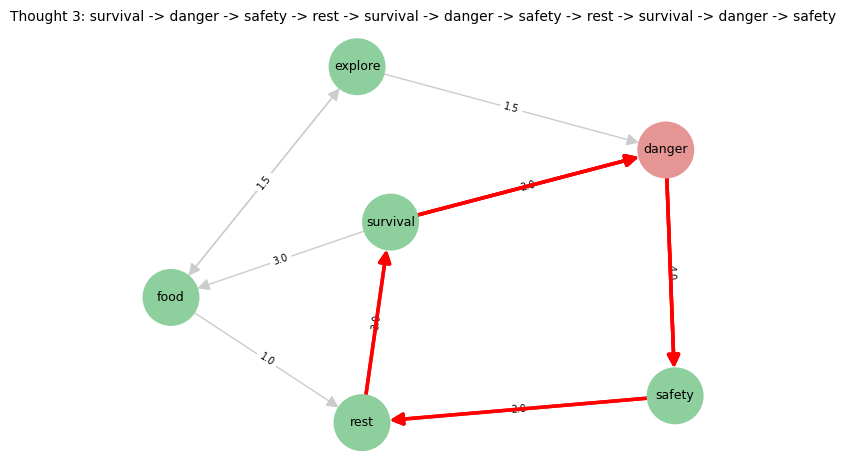

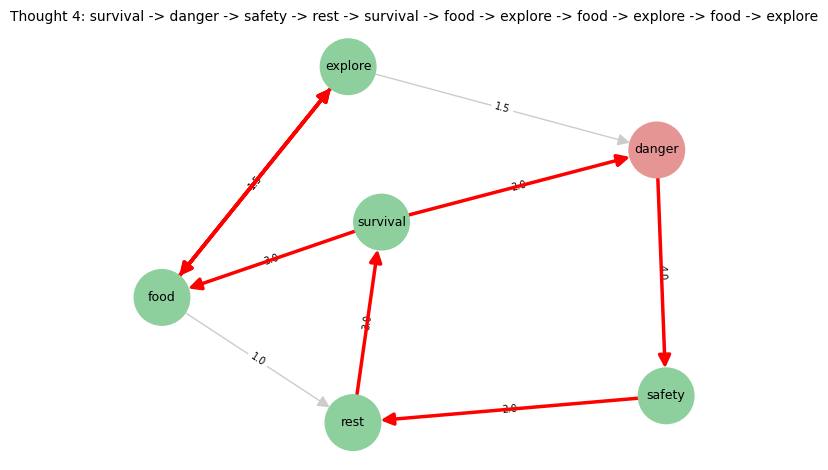

In [10]:
from evolving_agents.metrics import coverage, thought_payoff
from evolving_agents.thought import thought_loop_tracked
from evolving_agents.visualize import draw_payoff_curves


import random
random.seed(42)   # freeze randomness so your documented numbers reproduce

traces = []
curves = []
for i in range(4):
    trace, curve = thought_loop_tracked(G, "survival", max_steps=10)
    traces.append(trace)
    curves.append(curve)
    print(f"thought {i+1}: coverage={coverage(G, trace)}  payoff={thought_payoff(G, trace)}")
    print(f"   {' -> '.join(trace)}\n")

# plot all 4 payoff curves together
draw_payoff_curves(curves, labels=[f"thought {i+1}" for i in range(4)])

# draw each thought's path on the graph, one at a time
for i, trace in enumerate(traces):
    draw_graph(G, path=trace, title=f"Thought {i+1}")

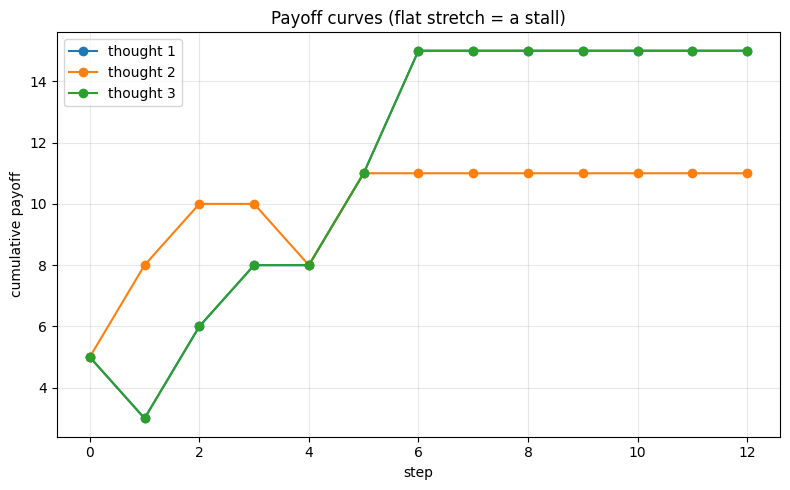